## <font size=5> <strong>ML-Based Cardiovascular Disease Prediction




## I. Importing essential libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import os
print(os.listdir())

import warnings
warnings.filterwarnings('ignore')

['.config', 'heart_disease_data.csv', 'sample_data']


## II. Importing and understanding our dataset

In [ ]:
dataset = pd.read_csv("heart_disease1_data.csv")

#### Verifying it as a 'dataframe' object in pandas

In [ ]:
type(dataset)

pandas.core.frame.DataFrame

#### Shape of dataset

In [ ]:
dataset.shape

(303, 15)

#### Printing out a few columns

In [ ]:
dataset.head(5)

,ID,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,10001,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,10002,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,10003,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,10004,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,10005,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
dataset.sample(5)

,ID,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
254,10255,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0
17,10018,66,0,3,150,226,0,1,114,0,2.6,0,0,2,1
86,10087,68,1,2,118,277,0,1,151,0,1.0,2,1,3,1
63,10064,41,1,1,135,203,0,1,132,0,0.0,1,0,1,1
1,10002,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1


#### Description

In [ ]:
dataset.describe()

,ID,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,10152.000000,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,87.612784,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,10001.000000,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10076.500000,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,10152.000000,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,10227.500000,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,10303.000000,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        303 non-null    int64  
 1   age       303 non-null    int64  
 2   sex       303 non-null    int64  
 3   cp        303 non-null    int64  
 4   trestbps  303 non-null    int64  
 5   chol      303 non-null    int64  
 6   fbs       303 non-null    int64  
 7   restecg   303 non-null    int64  
 8   thalach   303 non-null    int64  
 9   exang     303 non-null    int64  
 10  oldpeak   303 non-null    float64
 11  slope     303 non-null    int64  
 12  ca        303 non-null    int64  
 13  thal      303 non-null    int64  
 14  target    303 non-null    int64  
dtypes: float64(1), int64(14)
memory usage: 35.6 KB


In [ ]:
import pandas as pd


!pip install ydata-profiling
from ydata_profiling import ProfileReport


data = {'col1': [1, 2, 3, 4, 5],
        'col2': ['a', 'b', 'c', 'd', 'e'],
        'col3': [1.1, 2.2, 3.3, 4.4, 5.5]}
df = pd.DataFrame(data)


profile = ProfileReport(df)


profile.to_file("profile_report.html")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.6/390.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 57.2 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=4ed20a88241bf9e7ed4e1f5c85d6d68d90cffc59be9cf05a4e09bea6534d874c
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#### Let's understand our columns better:

In [ ]:
info = ["age","1: male, 0: female","chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic","resting blood pressure"," serum cholestoral in mg/dl","fasting blood sugar > 120 mg/dl","resting electrocardiographic results (values 0,1,2)"," maximum heart rate achieved","exercise induced angina","oldpeak = ST depression induced by exercise relative to rest","the slope of the peak exercise ST segment","number of major vessels (0-3) colored by flourosopy","thal: 3 = normal; 6 = fixed defect; 7 = reversable defect"]



for i in range(len(info)):
    print(dataset.columns[i]+":\t\t\t"+info[i])

ID:			age
age:			1: male, 0: female
sex:			chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic
cp:			resting blood pressure
trestbps:			 serum cholestoral in mg/dl
chol:			fasting blood sugar > 120 mg/dl
fbs:			resting electrocardiographic results (values 0,1,2)
restecg:			 maximum heart rate achieved
thalach:			exercise induced angina
exang:			oldpeak = ST depression induced by exercise relative to rest
oldpeak:			the slope of the peak exercise ST segment
slope:			number of major vessels (0-3) colored by flourosopy
ca:			thal: 3 = normal; 6 = fixed defect; 7 = reversable defect


#### Analysing the 'target' variable

In [ ]:
dataset["target"].describe()

,target
count,303.000000
mean,0.544554
std,0.498835
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
dataset["target"].unique()

array([1, 0])

#### Clearly, this is a classification problem, with the target variable having values '0' and '1'

### Checking correlation between columns

In [ ]:
print(dataset.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
ID          0.862585
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


In [ ]:
#This shows that most columns are moderately correlated with target, but 'fbs' is very weakly correlated.

## Exploratory Data Analysis (EDA)

### First, analysing the target variable:

target
1    165
0    138
Name: count, dtype: int64


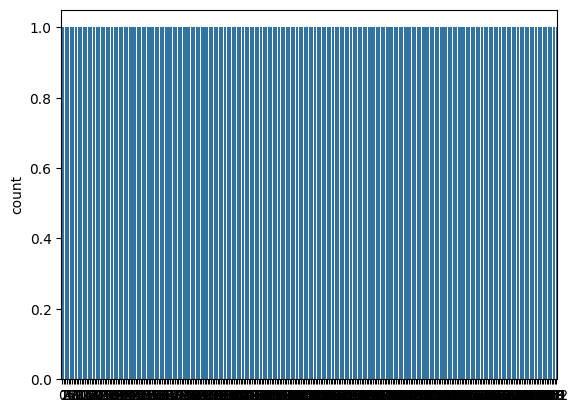

In [ ]:
y = dataset["target"]

sns.countplot(y)


target_temp = dataset.target.value_counts()

print(target_temp)

In [ ]:
print("Percentage of patience without heart problems: "+str(round(target_temp[0]*100/303,2)))
print("Percentage of patience with heart problems: "+str(round(target_temp[1]*100/303,2)))

#Alternatively,
# print("Percentage of patience with heart problems: "+str(y.where(y==1).count()*100/303))
# print("Percentage of patience with heart problems: "+str(y.where(y==0).count()*100/303))

# #Or,
# countNoDisease = len(df[df.target == 0])
# countHaveDisease = len(df[df.target == 1])

Percentage of patience without heart problems: 45.54
Percentage of patience with heart problems: 54.46


### We'll analyse 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca' and 'thal' features

### Analysing the 'Sex' feature

In [ ]:
dataset["sex"].unique()

array([1, 0])

##### We notice, that as expected, the 'sex' feature has 2 unique features

In [ ]:
#sns.barplot(dataset["sex"],y)

##### We notice, that females are more likely to have heart problems than males

### Analysing the 'Chest Pain Type' feature

<Axes: xlabel='sex', ylabel='target'>

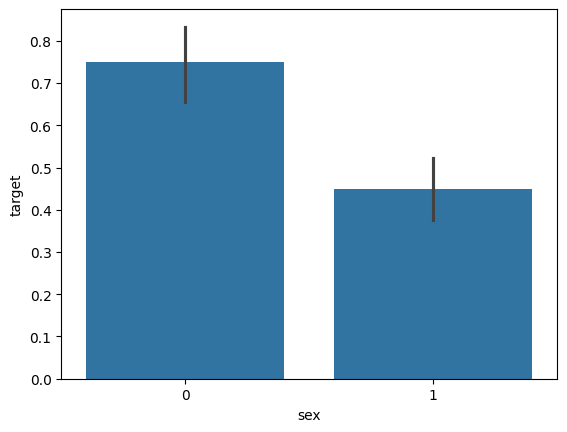

In [ ]:
sns.barplot(x=dataset["sex"], y=y) # Specify x and y arguments using keyword arguments to avoid the TypeError


In [ ]:
dataset["cp"].unique()

array([3, 2, 1, 0])

##### As expected, the CP feature has values from 0 to 3

<Axes: xlabel='cp', ylabel='target'>

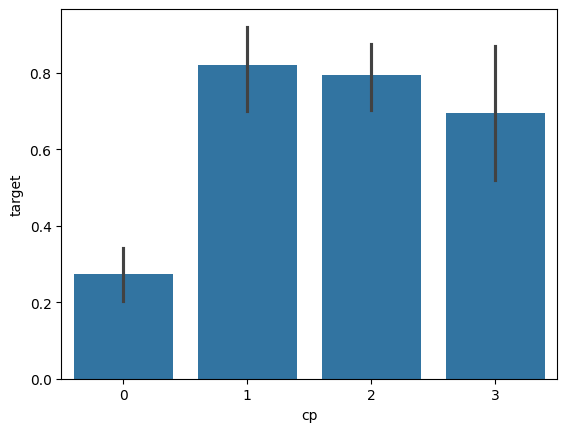

In [ ]:
sns.barplot(x=dataset["cp"], y=y) # Specify x and y arguments using keyword arguments to avoid the TypeError

##### We notice, that chest pain of '0', i.e. the ones with typical angina are much less likely to have heart problems

### Analysing the FBS feature

In [ ]:
dataset["fbs"].describe()

,fbs
count,303.000000
mean,0.148515
std,0.356198
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
dataset["fbs"].unique()

array([1, 0])

<Axes: xlabel='fbs', ylabel='target'>

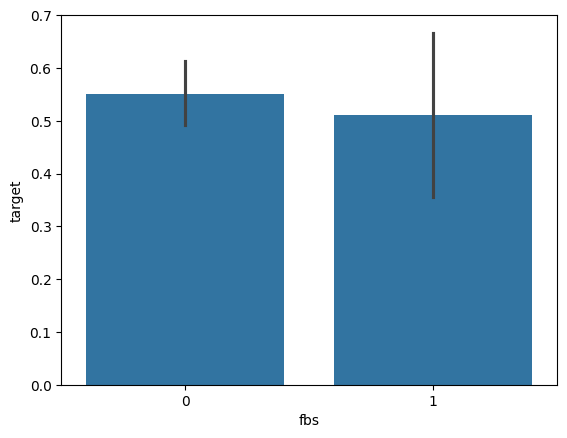

In [ ]:
sns.barplot(x="fbs", y=y, data=dataset)

##### Nothing extraordinary here

### Analysing the restecg feature

In [ ]:
dataset["restecg"].unique()

array([0, 1, 2])

<Axes: xlabel='restecg', ylabel='target'>

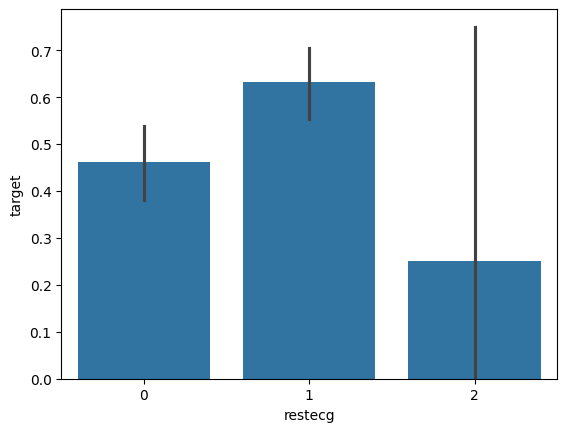

In [ ]:
sns.barplot(x=dataset["restecg"], y=y) # Specify x and y using keyword arguments.

##### We realize that people with restecg '1' and '0' are much more likely to have a heart disease than with restecg '2'

### Analysing the 'exang' feature

In [ ]:
dataset["exang"].unique()

array([0, 1])

<Axes: xlabel='exang', ylabel='target'>

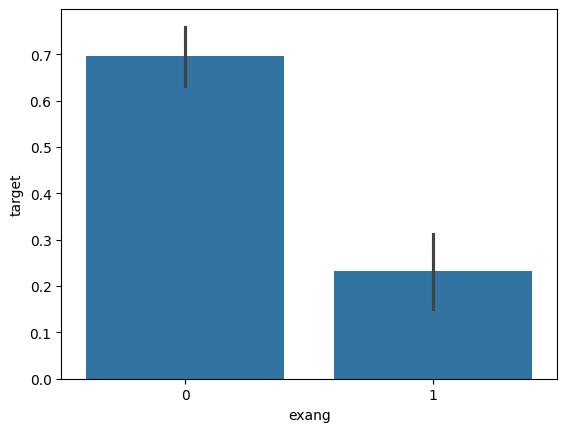

In [ ]:
sns.barplot(x=dataset["exang"], y=y) # Specify x and y using keyword arguments.

##### People with exang=1 i.e. Exercise induced angina are much less likely to have heart problems

### Analysing the Slope feature

In [ ]:
dataset["slope"].unique()

array([0, 2, 1])

<Axes: xlabel='slope', ylabel='target'>

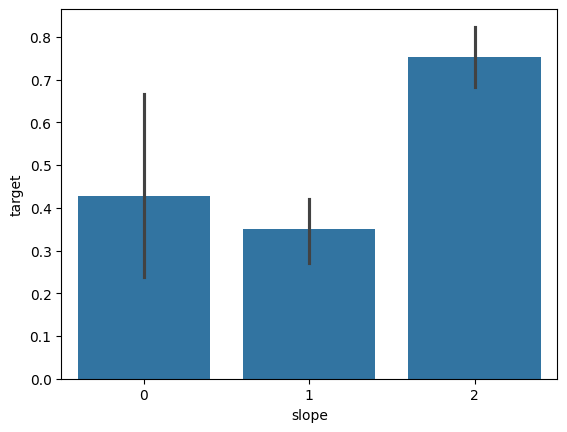

In [ ]:
sns.barplot(x=dataset["slope"],y=y)

##### We observe, that Slope '2' causes heart pain much more than Slope '0' and '1'

### Analysing the 'ca' feature

In [ ]:
#number of major vessels (0-3) colored by flourosopy

In [ ]:
dataset["ca"].unique()

array([0, 2, 1, 3, 4])

<Axes: ylabel='count'>

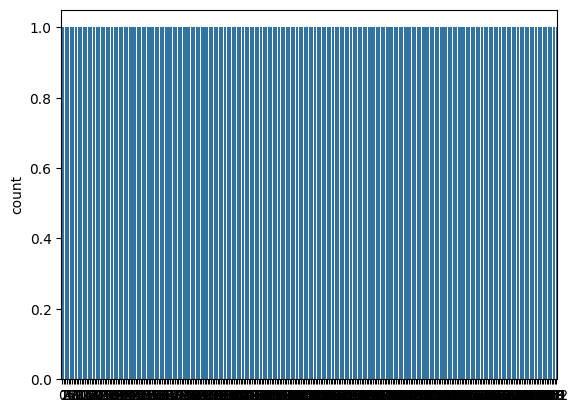

In [ ]:
sns.countplot(dataset["ca"])

<Axes: xlabel='ca', ylabel='target'>

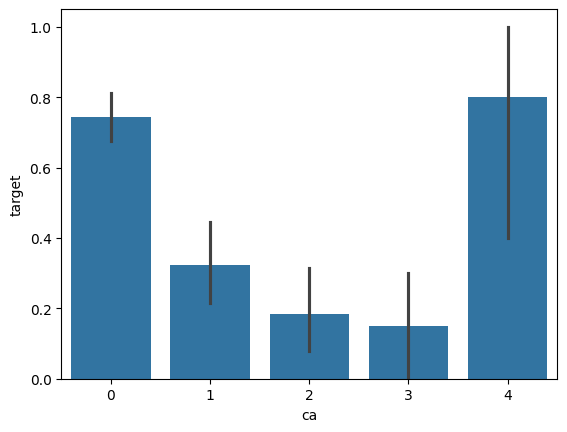

In [ ]:
sns.barplot(x=dataset["ca"],y=y)

##### ca=4 has astonishingly large number of heart patients

In [ ]:
### Analysing the 'thal' feature

In [ ]:
dataset["thal"].unique()

array([1, 2, 3, 0])

<Axes: xlabel='thal', ylabel='target'>

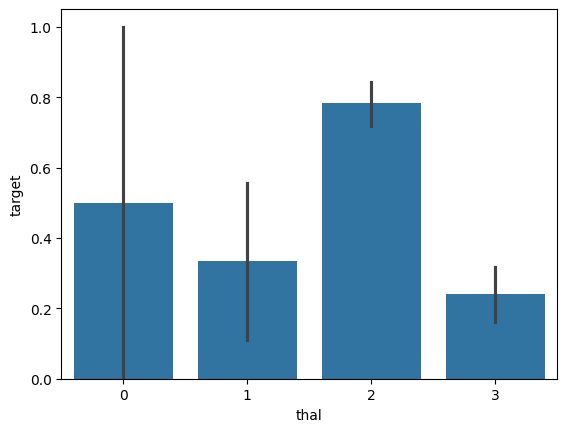

In [ ]:
sns.barplot(x=dataset["thal"],y=y)

<Axes: xlabel='thal', ylabel='Density'>

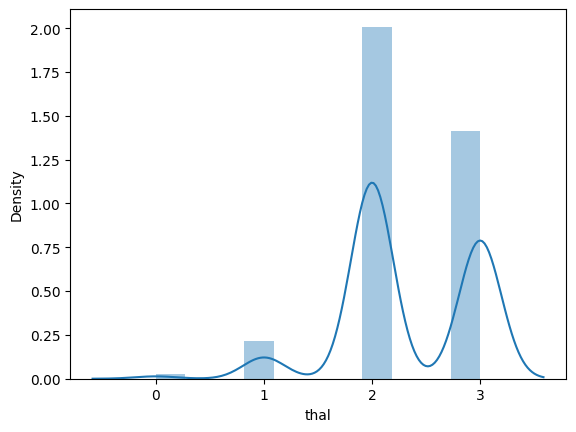

In [ ]:
sns.distplot(dataset["thal"])

## IV. Train Test split

In [ ]:
from sklearn.model_selection import train_test_split

predictors = dataset.drop("target",axis=1)
target = dataset["target"]

X_train,X_test,Y_train,Y_test = train_test_split(predictors,target,test_size=0.20,random_state=0)

In [ ]:
X_train.shape

(242, 14)

In [ ]:
X_test.shape

(61, 14)

In [ ]:
Y_train.shape

(242,)

In [ ]:
Y_test.shape

(61,)

## V. Model Fitting

In [ ]:
from sklearn.metrics import accuracy_score

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,Y_train)

Y_pred_lr = lr.predict(X_test)

In [ ]:
Y_pred_lr.shape

(61,)

In [ ]:
score_lr = round(accuracy_score(Y_pred_lr,Y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")

The accuracy score achieved using Logistic Regression is: 83.61 %


### Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train,Y_train)

Y_pred_nb = nb.predict(X_test)

In [ ]:
Y_pred_nb.shape

(61,)

In [ ]:
score_nb = round(accuracy_score(Y_pred_nb,Y_test)*100,2)

print("The accuracy score achieved using Naive Bayes is: "+str(score_nb)+" %")

The accuracy score achieved using Naive Bayes is: 100.0 %


### SVM

In [ ]:
from sklearn import svm

sv = svm.SVC(kernel='linear')

sv.fit(X_train, Y_train)

Y_pred_svm = sv.predict(X_test)

In [ ]:
Y_pred_svm.shape

(61,)

In [ ]:
score_svm = round(accuracy_score(Y_pred_svm,Y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_svm)+" %")

The accuracy score achieved using Linear SVM is: 100.0 %


### K Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,Y_train)
Y_pred_knn=knn.predict(X_test)

In [ ]:
Y_pred_knn.shape

(61,)

In [ ]:
score_knn = round(accuracy_score(Y_pred_knn,Y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")

The accuracy score achieved using KNN is: 100.0 %


### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

max_accuracy = 0


for x in range(200):
    dt = DecisionTreeClassifier(random_state=x)
    dt.fit(X_train,Y_train)
    Y_pred_dt = dt.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x

#print(max_accuracy)
#print(best_x)


dt = DecisionTreeClassifier(random_state=best_x)
dt.fit(X_train,Y_train)
Y_pred_dt = dt.predict(X_test)

In [ ]:
print(Y_pred_dt.shape)

(61,)


In [ ]:
score_dt = round(accuracy_score(Y_pred_dt,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")

The accuracy score achieved using Decision Tree is: 100.0 %


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

max_accuracy = 0


for x in range(2000):
    rf = RandomForestClassifier(random_state=x)
    rf.fit(X_train,Y_train)
    Y_pred_rf = rf.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_rf,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x

#print(max_accuracy)
#print(best_x)

rf = RandomForestClassifier(random_state=best_x)
rf.fit(X_train,Y_train)
Y_pred_rf = rf.predict(X_test)

In [ ]:
Y_pred_rf.shape

(61,)

In [ ]:
score_rf = round(accuracy_score(Y_pred_rf,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_rf)+" %")

The accuracy score achieved using Decision Tree is: 100.0 %


### XGBoost

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
Y_pred_xgb.shape

(61,)

In [ ]:
score_xgb = round(accuracy_score(Y_pred_xgb,Y_test)*100,2)

print("The accuracy score achieved using XGBoost is: "+str(score_xgb)+" %")

The accuracy score achieved using XGBoost is: 100.0 %


### Neural Network

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
# https://stats.stackexchange.com/a/136542 helped a lot in avoiding overfitting

model = Sequential()
model.add(Dense(11,activation='relu',input_dim=14))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
model.fit(X_train,Y_train,epochs=30)

In [ ]:
Y_pred_nn = model.predict(X_test)

In [ ]:
Y_pred_nn.shape

In [ ]:
rounded = [round(x[0]) for x in Y_pred_nn]

Y_pred_nn = rounded

In [ ]:
score_nn = round(accuracy_score(Y_pred_nn,Y_test)*100,2)

print("The accuracy score achieved using Neural Network is: "+str(score_nn)+" %")

#Note: Accuracy of 85% can be achieved on the test set, by setting epochs=2000, and number of nodes = 11.

## VI. Output final score

In [ ]:
scores = [score_lr,score_nb,score_svm,score_knn,score_dt,score_rf,score_xgb,score_nn]
algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine","K-Nearest Neighbors","Decision Tree","Random Forest","XGBoost","Neural Network"]

for i in range(len(algorithms)):
    print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")

sns.barplot(x=algorithms,y=scores) # Pass x and y as named arguments

### Hey arbaaz there random forest has good result as compare to other algorithms <br> <br>

In [ ]:
# prompt: use random forest model for prediction

# Assuming X_test is your test data
Y_pred_rf = rf.predict(X_test)
for i in Y_pred_rf:
    if i == 1:
        print("The patient has heart disease.")
    else:
        print("The patient does not have heart disease.")

# Y_pred_rf now contains the predictions made by the Random Forest model
# You can print or analyze these predictions as needed.

#print(Y_pred_rf)


In [ ]:
# prompt: use root mean squared error for all the above models

from sklearn.metrics import mean_squared_error
import math

# ... (Your existing code for model training and prediction) ...

# Calculate RMSE for each model
rmse_lr = math.sqrt(mean_squared_error(Y_test, Y_pred_lr))
rmse_nb = math.sqrt(mean_squared_error(Y_test, Y_pred_nb))
rmse_svm = math.sqrt(mean_squared_error(Y_test, Y_pred_svm))
rmse_knn = math.sqrt(mean_squared_error(Y_test, Y_pred_knn))
rmse_dt = math.sqrt(mean_squared_error(Y_test, Y_pred_dt))
rmse_rf = math.sqrt(mean_squared_error(Y_test, Y_pred_rf))
rmse_xgb = math.sqrt(mean_squared_error(Y_test, Y_pred_xgb))
rmse_nn = math.sqrt(mean_squared_error(Y_test, Y_pred_nn))

# Print RMSE for each model
print("RMSE for Logistic Regression:", rmse_lr)
print("RMSE for Naive Bayes:", rmse_nb)
print("RMSE for SVM:", rmse_svm)
print("RMSE for KNN:", rmse_knn)
print("RMSE for Decision Tree:", rmse_dt)
print("RMSE for Random Forest:", rmse_rf)
print("RMSE for XGBoost:", rmse_xgb)
print("RMSE for Neural Network:", rmse_nn)

# You can also create a bar plot to compare RMSE values visually
rmse_scores = [rmse_lr, rmse_nb, rmse_svm, rmse_knn, rmse_dt, rmse_rf, rmse_xgb, rmse_nn]
sns.set(rc={'figure.figsize':(15,8)})
plt.xlabel("Algorithms")
plt.ylabel("RMSE")
sns.barplot(x=algorithms, y=rmse_scores)
plt.show()


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Assuming you have already trained your KNN model and it's named 'knn'
# and X_test is your test data

Y_pred_knn = knn.predict(X_test)

for i in Y_pred_knn:
    if i == 1:
        print("The patient has heart disease.")
    else:
        print("The patient does not have heart disease.")

In [ ]:
import pandas as pd

# 1. Load the data
data = pd.read_csv('heart_disease_data.csv')

# 2. Filter data for patients with heart disease (target = 1)
heart_disease_data = data[data['target'] == 1]

# 3. Calculate the average of a relevant feature
# Replace 'relevant_feature' with the actual column name you want to average, for example, 'chol'
average_value = heart_disease_data['chol'].mean() # Changed 'relevant_feature' to 'chol'

# 4. Add a new 'stage' column based on the average
data['stage'] = 0  # Initialize the stage column to 0

# Assign stages based on the average
# Changed 'relevant_feature' to 'chol' in the following lines
data.loc[(data['target'] == 1) & (data['chol'] > average_value), 'stage'] = 2  # Stage 2
data.loc[(data['target'] == 1) & (data['chol'] <= average_value), 'stage'] = 1  # Stage 1


# 5. Print the updated DataFrame with the 'stage' column
print(data)

Classifying Heart Disease according to stages


In [ ]:
import pandas as pd

# 1. Load the data
data = pd.read_csv('heart_disease_data.csv')

# 2. Filter data for patients with heart disease (target = 1)
heart_disease_data = data[data['target'] == 1]

# 3. Calculate the average of 'chol' for staging
average_chol = heart_disease_data['chol'].mean()

# 4. Add a new 'stage' column based on the average 'chol'
data['stage'] = 0  # Initialize the stage column to 0
data.loc[(data['target'] == 1) & (data['chol'] > average_chol), 'stage'] = 2  # Stage 2
data.loc[(data['target'] == 1) & (data['chol'] <= average_chol), 'stage'] = 1  # Stage 1

# 5. Print the ID, result, and stage for positive cases
for index, row in data[data['target'] == 1].iterrows():
    print(f"ID: {row['ID']}, Result: Heart Disease Positive, Stage: {row['stage']}")

Visual Representation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
data = pd.read_csv('heart_disease_data.csv')

# 2. Filter data for patients with heart disease (target = 1)
heart_disease_data = data[data['target'] == 1]

# 3. Calculate the average of 'chol' for staging
average_chol = heart_disease_data['chol'].mean()

# 4. Add a new 'stage' column based on the average 'chol'
data['stage'] = 0  # Initialize the stage column to 0
data.loc[(data['target'] == 1) & (data['chol'] > average_chol), 'stage'] = 2  # Stage 2
data.loc[(data['target'] == 1) & (data['chol'] <= average_chol), 'stage'] = 1  # Stage 1

# 5. Visualizations

# Scatter plot for age vs. chol, colored by target and sized by stage
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='chol', hue='target', size='stage', data=data)
plt.title('Age vs. Cholesterol with Target and Stage')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()

# Bar plot for the distribution of stages within each target group
plt.figure(figsize=(8, 5))
sns.countplot(x='target', hue='stage', data=data)
plt.title('Distribution of Stages within Target Groups')
plt.xlabel('Target (0: No Heart Disease, 1: Heart Disease)')
plt.ylabel('Count')
plt.show()

Individual Report


*** Patient Report ***
Patient ID: 10045
Heart Disease: Positive
Stage: 2


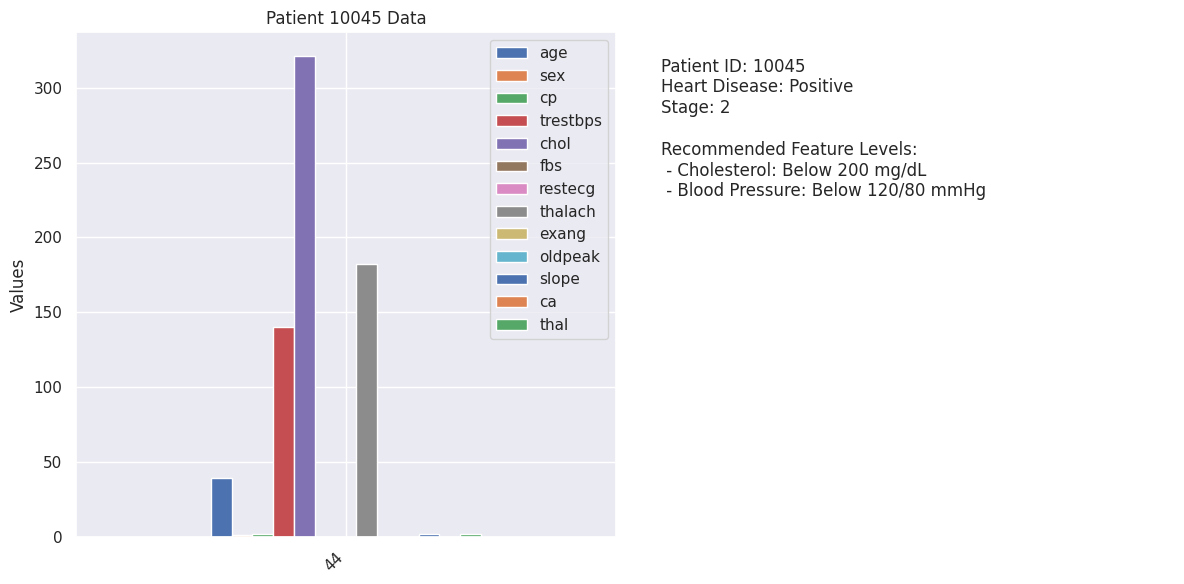

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
data = pd.read_csv('heart_disease_data.csv')

# 2. Filter data for patients with heart disease (target = 1)
heart_disease_data = data[data['target'] == 1]

# 3. Calculate the average of 'chol' for staging
average_chol = heart_disease_data['chol'].mean()

# 4. Add a new 'stage' column based on the average 'chol'
data['stage'] = 0  # Initialize the stage column to 0
data.loc[(data['target'] == 1) & (data['chol'] > average_chol), 'stage'] = 2  # Stage 2
data.loc[(data['target'] == 1) & (data['chol'] <= average_chol), 'stage'] = 1  # Stage 1

# 5. Function to display data for a specific ID
def display_patient_report(patient_id):
    # Filter data for the given patient ID
    patient_data = data[data['ID'] == patient_id]

    if patient_data.empty:
        print(f"No data found for Patient ID: {patient_id}")
        return

    # Extract relevant information
    target = patient_data['target'].values[0]
    stage = patient_data['stage'].values[0]

    # Print the report
    print("\n*** Patient Report ***")
    print(f"Patient ID: {patient_id}")
    print(f"Heart Disease: {'Positive' if target == 1 else 'Negative'}")
    if target == 1:
        print(f"Stage: {stage}")

    # Visualize the data using a bar plot
    plt.figure(figsize=(12, 6))

    # --- Bar plot for patient data ---
    ax1 = plt.subplot(1, 2, 1)  # Create a subplot for the bar plot
    patient_data.drop(['ID', 'target', 'stage'], axis=1).plot(kind='bar', ax=ax1)
    plt.title(f"Patient {patient_id} Data")
    plt.ylabel("Values")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()


    # --- Text box for report summary ---
    ax2 = plt.subplot(1, 2, 2)  # Create a subplot for the text box
    ax2.axis('off')  # Turn off axis for the text box

    report_text = f"Patient ID: {patient_id}\n"
    report_text += f"Heart Disease: {'Positive' if target == 1 else 'Negative'}\n"
    if target == 1:
        report_text += f"Stage: {stage}\n\n"

    # Add recommended feature levels (example - you should customize this)
    report_text += "Recommended Feature Levels:\n"
    report_text += " - Cholesterol: Below 200 mg/dL\n"
    report_text += " - Blood Pressure: Below 120/80 mmHg\n"
    # Add more features and their recommended levels

    ax2.text(0.05, 0.95, report_text, fontsize=12, va='top')

    plt.show()

# 6. Loop to repeatedly ask for patient IDs
while True:
    patient_id = input("Provide Patient ID (or type 'exit' to quit): ")

    if patient_id.lower() == 'exit':
        break

    try:
        patient_id = int(patient_id)
        display_patient_report(patient_id)

        # Ask if the user wants to continue
        choice = input("Do you want to continue? (yes/no): ")
        if choice.lower() != 'yes':
            break  # Exit the loop if the choice is not 'yes'

    except ValueError:
        print("Invalid input. Please enter a valid Patient ID or 'exit'.")
        print("Invalid input. Please enter a valid Patient ID or 'exit'.")